In [1]:
import os
import random
import torch
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.decomposition import PCA
from collections import defaultdict
from scipy.stats import wasserstein_distance

###############################################################################
# Arguments
###############################################################################
args = {
    "models": [
        "nlpaueb/sec-bert-base",
        "bert-base-uncased"
    ],
    "datasets": [
        {
            "name": "yelp_review_full",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "wikitext",
            "config": "wikitext-2-raw-v1",
            "split": "train",
            "text_column": "text"
        },
        {
            "name": "ag_news",
            "config": None,
            "split": "train",
            "text_column": "text"
        },
    ],
    "max_texts": 100,
    "batch_size": 64,
    "drift_strengths": [0.0, 0.25, 0.5, 0.75, 1.0],
    "pca_components": 2,
    "output_dir": "results_multidataset",
    "hist_bins": 30,  # for 2D histogram
    "num_seeds": 3,   # Number of random seeds for repeated trials
    "kl_eps": 1e-12,  # Smoothing parameter for KL, JS, etc.
    "use_adaptive_gamma": True  # Whether to select gamma adaptively for MMD
}
os.makedirs(args["output_dir"], exist_ok=True)

###############################################################################
# Utility Functions
###############################################################################
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def batch_generator(data, batch_size=32):
    for i in range(0, len(data), batch_size):
        yield data[i : i + batch_size]

def extract_cls_embeddings(model, tokenizer, texts, device):
    encodings = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    )
    input_ids = encodings["input_ids"].to(device)
    attention_mask = encodings["attention_mask"].to(device)
    with torch.no_grad():
        outputs = model(input_ids, attention_mask=attention_mask)
        cls_embeddings = outputs.last_hidden_state[:, 0, :]
    return cls_embeddings.cpu().numpy()

def introduce_gradual_drift(text_list, fraction_shuffle=0.5):
    """
    Simple 'drift' function that shuffles a fraction of words in each text.
    """
    new_texts = []
    for txt in text_list:
        words = txt.split()
        if len(words) < 2:
            new_texts.append(txt)
            continue
        k = int(len(words) * fraction_shuffle)
        if k < 1:
            new_texts.append(txt)
            continue
        indices = list(range(len(words)))
        random.shuffle(indices)
        shuffle_indices = indices[:k]
        to_shuffle = [words[i] for i in shuffle_indices]
        random.shuffle(to_shuffle)
        for i, idx in enumerate(shuffle_indices):
            words[idx] = to_shuffle[i]
        new_texts.append(" ".join(words))
    return new_texts

###############################################################################
# 1) Building Distribution Histograms in 2D
###############################################################################
def build_2d_hist(embs_2d, bins=30):
    """
    Given Nx2 embeddings, build a 2D histogram and return
    a normalized distribution (matrix) plus bin edges.
    """
    hist, xedges, yedges = np.histogram2d(
        embs_2d[:, 0], embs_2d[:, 1], bins=bins, density=True
    )
    return hist, xedges, yedges

###############################################################################
# 2) Common Distribution-Based Distances or Divergences
###############################################################################
def safe_prob(p, eps=1e-12):
    """
    Utility to avoid zeros for logs or divisions.
    """
    return np.maximum(p, eps)

def kl_divergence(p, q, kl_eps=1e-12):
    """
    Discrete KL Divergence:
        KL(P||Q) = sum_i p_i * log( p_i / q_i )
    """
    p_ = safe_prob(p, eps=kl_eps)
    q_ = safe_prob(q, eps=kl_eps)
    return np.sum(p_ * np.log(p_ / q_))

def js_divergence(p, q, kl_eps=1e-12):
    """
    Jensen-Shannon Divergence:
        JS(P||Q) = 0.5 * KL(P || M) + 0.5 * KL(Q || M)
        where M = 0.5*(P+Q)
    """
    p_ = safe_prob(p, eps=kl_eps)
    q_ = safe_prob(q, eps=kl_eps)
    m_ = 0.5 * (p_ + q_)
    return 0.5 * kl_divergence(p_, m_, kl_eps=kl_eps) + 0.5 * kl_divergence(q_, m_, kl_eps=kl_eps)

def hellinger_distance(p, q, kl_eps=1e-12):
    """
    Hellinger distance for discrete distributions:
        H^2(P, Q) = 1 - sum_i sqrt(p_i * q_i)
        => H(P, Q) = sqrt( H^2(...) )
    """
    p_ = np.sqrt(safe_prob(p, eps=kl_eps))
    q_ = np.sqrt(safe_prob(q, eps=kl_eps))
    return np.sqrt(np.sum((p_ - q_)**2) / 2.0)

def bhattacharyya_distance(p, q, kl_eps=1e-12):
    """
    Bhattacharyya distance:
        d_B(P, Q) = -ln( sum_i sqrt(p_i q_i) )
    """
    bc = np.sum(np.sqrt(safe_prob(p, eps=kl_eps) * safe_prob(q, eps=kl_eps)))
    # Clamp to avoid bc > 1.0 due to floating-point or smoothing
    bc = min(bc, 1.0)
    return -np.log(bc + 1e-12)

def compute_2d_hist_distance(baseline_embs, new_embs, measure="js",
                             bins=30, kl_eps=1e-12):
    """
    1) Build 2D histograms
    2) Compute the specified measure
    """
    hist_p, xedges, yedges = build_2d_hist(baseline_embs, bins=bins)
    hist_q, _, _ = build_2d_hist(new_embs, bins=[xedges, yedges])

    p = hist_p.flatten()
    q = hist_q.flatten()

    if measure == "kl":
        return kl_divergence(p, q, kl_eps=kl_eps)
    elif measure == "js":
        return js_divergence(p, q, kl_eps=kl_eps)
    elif measure == "hellinger":
        return hellinger_distance(p, q, kl_eps=kl_eps)
    elif measure == "bhattacharyya":
        return bhattacharyya_distance(p, q, kl_eps=kl_eps)
    else:
        raise ValueError(f"Unknown measure: {measure}")

###############################################################################
# 3) Simple MMD Computation (sample-based, no histogram)
###############################################################################
def rbf_kernel(x, y, gamma=1.0):
    x2 = np.sum(x**2, axis=1)[:, None]
    y2 = np.sum(y**2, axis=1)[None, :]
    dist2 = x2 + y2 - 2*np.dot(x, y.T)
    return np.exp(-gamma * dist2)

def compute_mmd(baseline_embs, new_embs, gamma=0.5):
    """
    MMD^2 = E[k(x,x')] + E[k(y,y')] - 2 E[k(x,y)]
    Return sqrt(MMD^2).
    """
    X = baseline_embs
    Y = new_embs
    XX = rbf_kernel(X, X, gamma=gamma)
    YY = rbf_kernel(Y, Y, gamma=gamma)
    XY = rbf_kernel(X, Y, gamma=gamma)
    m = len(X)
    n = len(Y)

    mmd2 = XX.sum() / (m**2) + YY.sum() / (n**2) - 2.0 * XY.sum() / (m*n)
    return np.sqrt(mmd2)

def auto_select_gamma(embs):
    """
    Simple heuristic: use gamma = 1/(2*median_of_pairwise_distance^2).
    """
    # Subsample if needed (for speed)
    sample = embs
    if len(embs) > 500:
        sample = embs[np.random.choice(len(embs), 500, replace=False)]
    dists = []
    for i in range(len(sample)-1):
        dist2 = np.sum((sample[i] - sample[i+1:])**2, axis=1)
        dists.append(dist2)
    dists = np.concatenate(dists)
    median_dist2 = np.median(dists)
    if median_dist2 <= 0.0:
        median_dist2 = 1e-6
    return 1.0 / (2.0 * median_dist2)

###############################################################################
# 4) Multi-D Wasserstein (Sum of 1D)
###############################################################################
def compute_wasserstein_1D_per_dim(baseline_embs, new_embs):
    d = baseline_embs.shape[1]
    w_sum = 0.0
    for i in range(d):
        w_sum += wasserstein_distance(baseline_embs[:, i], new_embs[:, i])
    return w_sum

###############################################################################
# 5) Main function for a single seed
###############################################################################
def run_experiment_single_seed(seed, args):
    # Set the random seed
    set_seed(seed)

    # Detect device
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    print(f"[Seed={seed}] Using device:", device)

    results = defaultdict(list)

    for dataset_info in args["datasets"]:
        dataset_name  = dataset_info["name"]
        dataset_config = dataset_info["config"]
        dataset_split = dataset_info["split"]
        text_col      = dataset_info["text_column"]

        print(f"[Seed={seed}] === Loading dataset: {dataset_name} ===")
        ds = load_dataset(dataset_name, dataset_config, split=dataset_split)
        texts = list(ds[text_col])
        random.shuffle(texts)
        if args["max_texts"] > 0 and len(texts) > args["max_texts"]:
            texts = texts[: args["max_texts"]]

        # We'll split the data in half: baseline vs. drift region
        half_point = len(texts) // 2
        baseline_texts = texts[:half_point]
        drift_texts    = texts[half_point:]

        for model_name in args["models"]:
            print(f"[Seed={seed}] --- Using Model: {model_name} ---")
            tokenizer = AutoTokenizer.from_pretrained(model_name)
            model = AutoModel.from_pretrained(model_name)
            model.to(device)
            model.eval()

            # Precompute baseline embeddings
            baseline_embs = []
            for b in batch_generator(baseline_texts, args["batch_size"]):
                emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                baseline_embs.append(emb_b)
            baseline_embs = np.concatenate(baseline_embs, axis=0)

            # Fit PCA on the baseline embeddings
            pca = PCA(n_components=args["pca_components"])
            pca.fit(baseline_embs)
            baseline_embs_2d = pca.transform(baseline_embs)

            # If we are doing an adaptive gamma for MMD, compute it now
            if args["use_adaptive_gamma"]:
                gamma_val = auto_select_gamma(baseline_embs)
            else:
                gamma_val = 0.5

            distribution_measures = ["kl","js","hellinger",
                                     "bhattacharyya","mmd","wasserstein"]

            for measure_name in distribution_measures:
                for drift_strength in args["drift_strengths"]:

                    # 1) Create drifted text
                    drifted_texts = introduce_gradual_drift(drift_texts,
                                                            fraction_shuffle=drift_strength)

                    # 2) Extract new embeddings
                    new_embs = []
                    for b in batch_generator(drifted_texts, args["batch_size"]):
                        emb_b = extract_cls_embeddings(model, tokenizer, b, device)
                        new_embs.append(emb_b)
                    new_embs = np.concatenate(new_embs, axis=0)
                    new_embs_2d = pca.transform(new_embs)

                    # 3) Compute measure
                    if measure_name in ["kl", "js", "hellinger", "bhattacharyya"]:
                        dist_val = compute_2d_hist_distance(
                            baseline_embs_2d,
                            new_embs_2d,
                            measure=measure_name,
                            bins=args["hist_bins"],
                            kl_eps=args["kl_eps"]
                        )
                    elif measure_name == "mmd":
                        dist_val = compute_mmd(
                            baseline_embs,
                            new_embs,
                            gamma=gamma_val
                        )
                    elif measure_name == "wasserstein":
                        dist_val = compute_wasserstein_1D_per_dim(
                            baseline_embs_2d,
                            new_embs_2d
                        )
                    else:
                        dist_val = None

                    # 4) Store results (note we include seed in the key)
                    key = (dataset_name, model_name, measure_name, drift_strength)
                    results[key].append(dist_val)

    return results

###############################################################################
# 6) Collect data across multiple seeds
###############################################################################
def collect_data_multiple_seeds(args):
    all_results = defaultdict(list)
    for seed in range(args["num_seeds"]):
        seed_results = run_experiment_single_seed(seed, args)
        # Merge seed_results into all_results
        for k, dist_vals in seed_results.items():
            all_results[k].extend(dist_vals)  # accumulate
    print("Data collection (all seeds) done!")
    return all_results

all_results = collect_data_multiple_seeds(args)


/Users/jasper.bruin/miniconda3/envs/driftwatch2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Seed=0] Using device: mps
[Seed=0] === Loading dataset: yelp_review_full ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: wikitext ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=0] === Loading dataset: ag_news ===
[Seed=0] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=0] --- Using Model: bert-base-uncased ---
[Seed=1] Using device: mps
[Seed=1] === Loading dataset: yelp_review_full ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=1] === Loading dataset: wikitext ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=1] === Loading dataset: ag_news ===
[Seed=1] --- Using Model: nlpaueb/sec-bert-base ---
[Seed=1] --- Using Model: bert-base-uncased ---
[Seed=2] Using device: mps
[Seed=2] === Loading dataset: yelp_review_full 

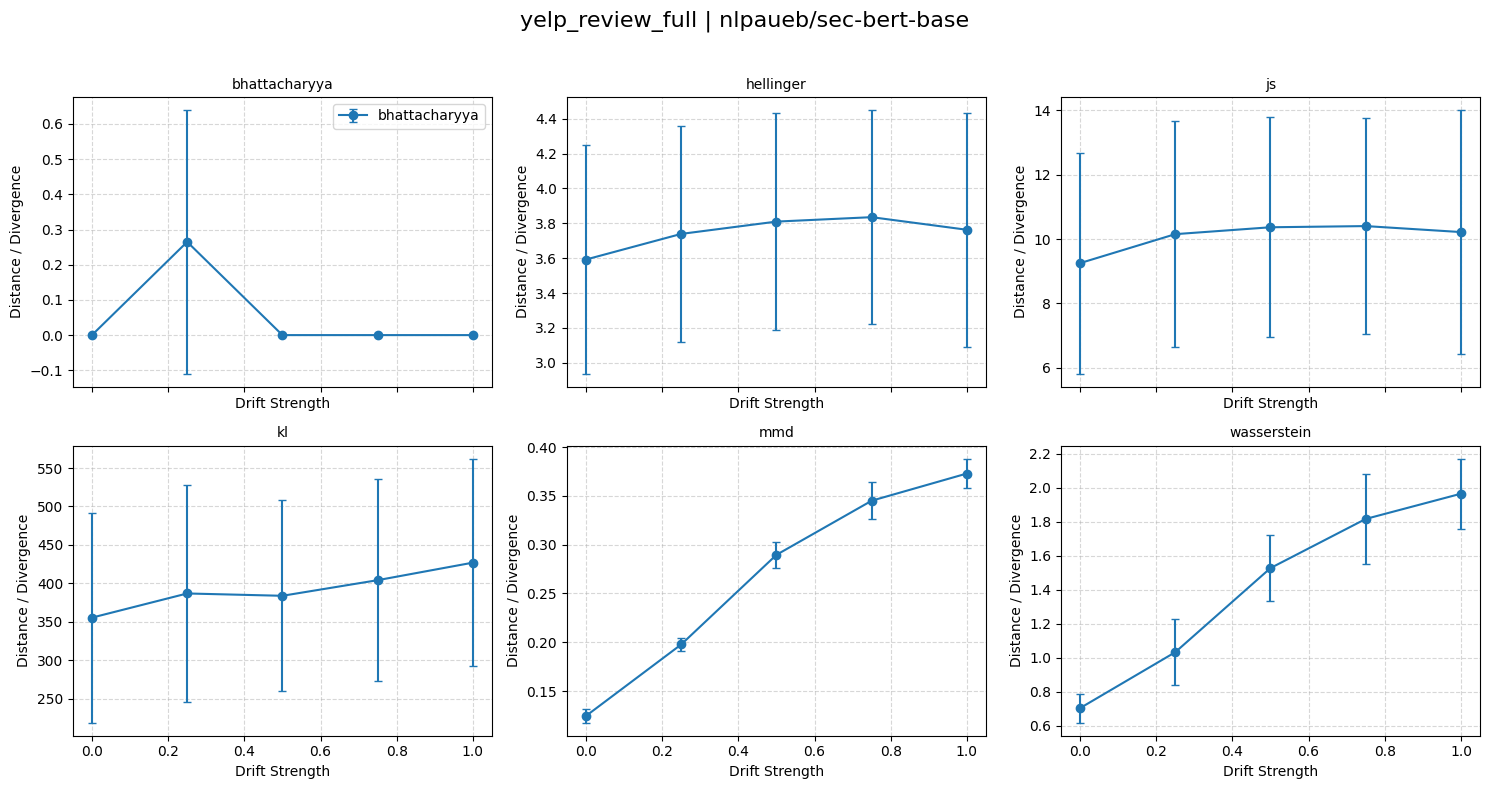

Saved figure: results_multidataset/yelp_review_full_nlpaueb_sec-bert-base_distribution_measures.png


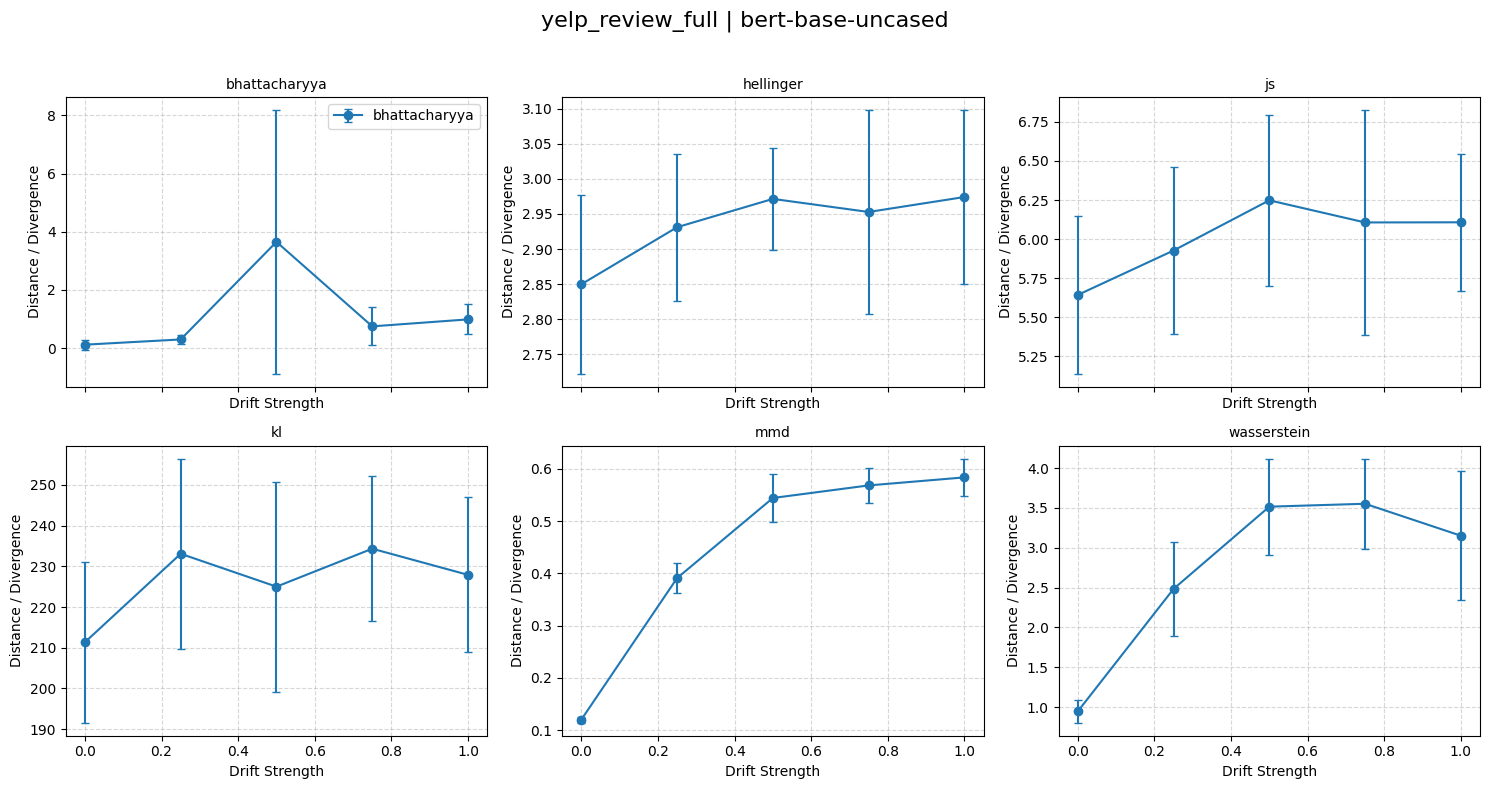

Saved figure: results_multidataset/yelp_review_full_bert-base-uncased_distribution_measures.png


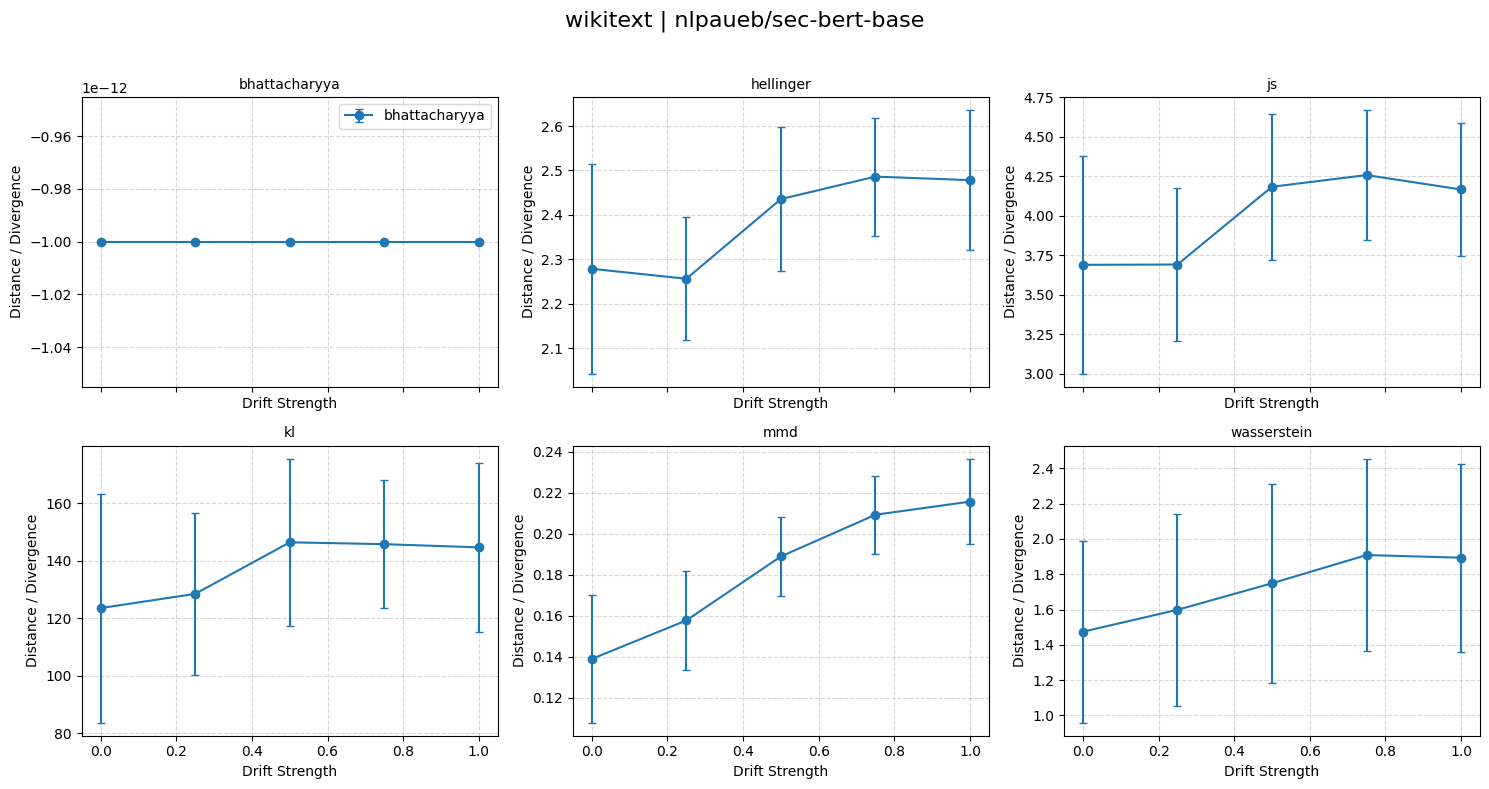

Saved figure: results_multidataset/wikitext_nlpaueb_sec-bert-base_distribution_measures.png


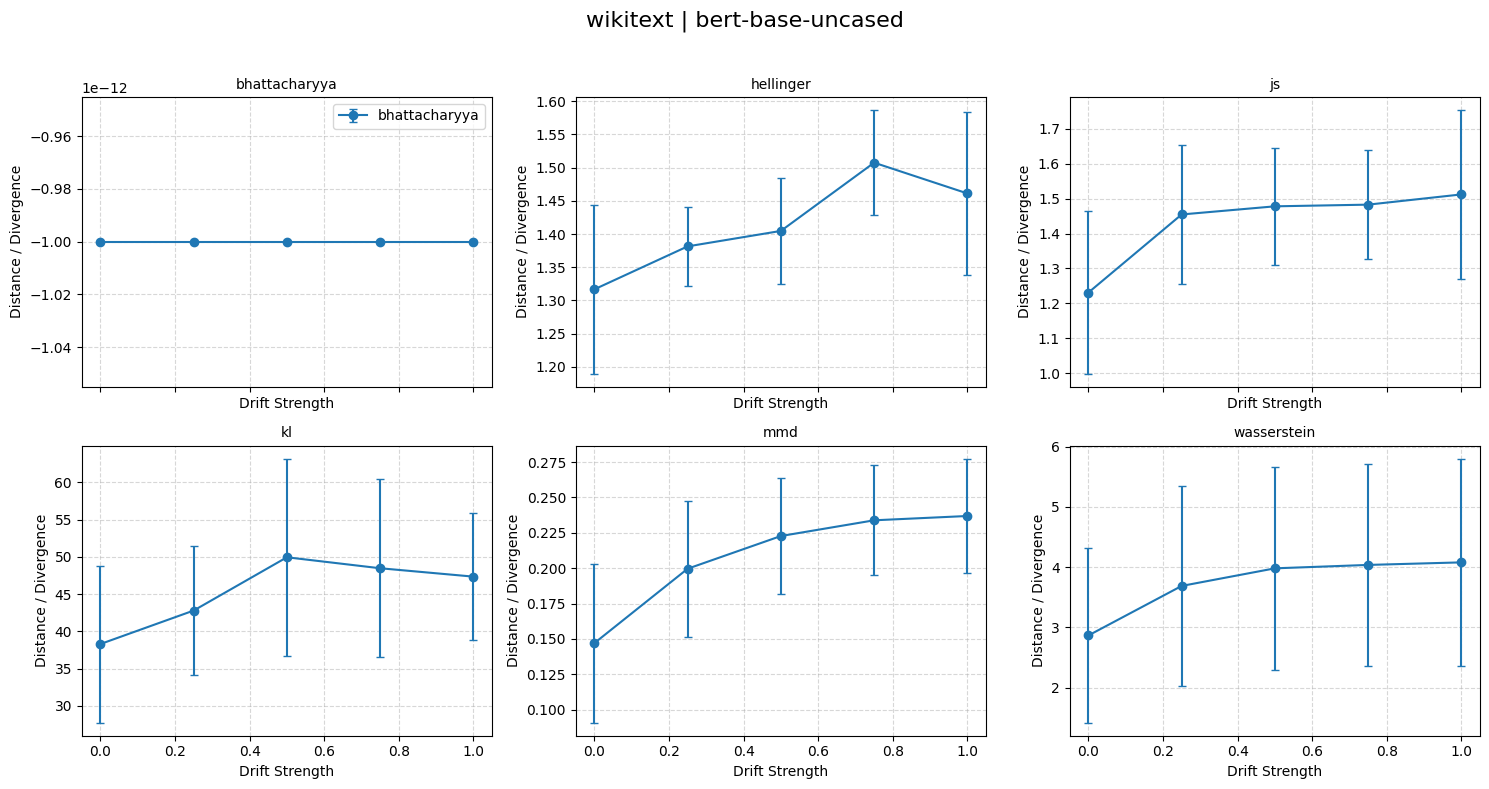

Saved figure: results_multidataset/wikitext_bert-base-uncased_distribution_measures.png


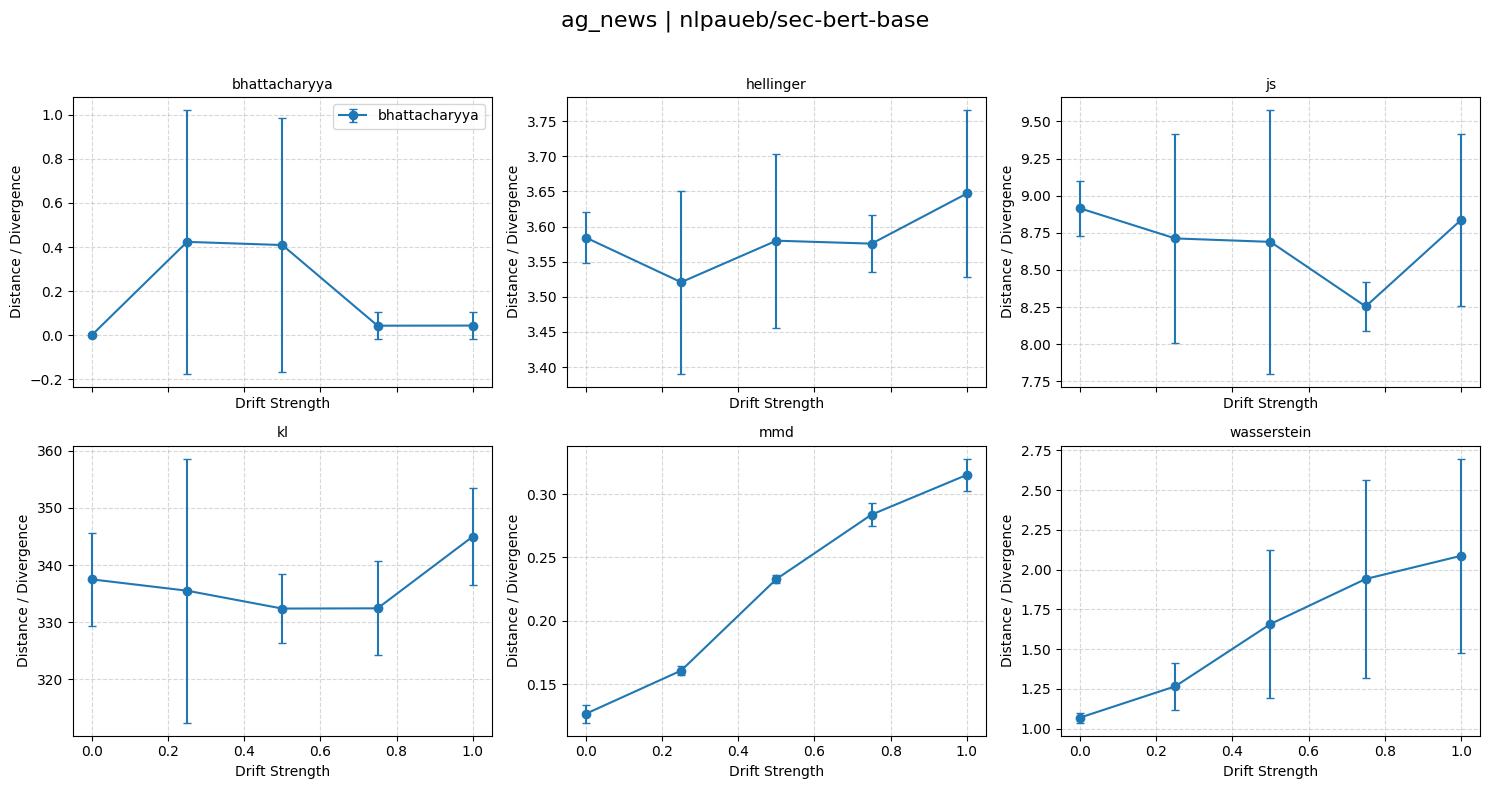

Saved figure: results_multidataset/ag_news_nlpaueb_sec-bert-base_distribution_measures.png


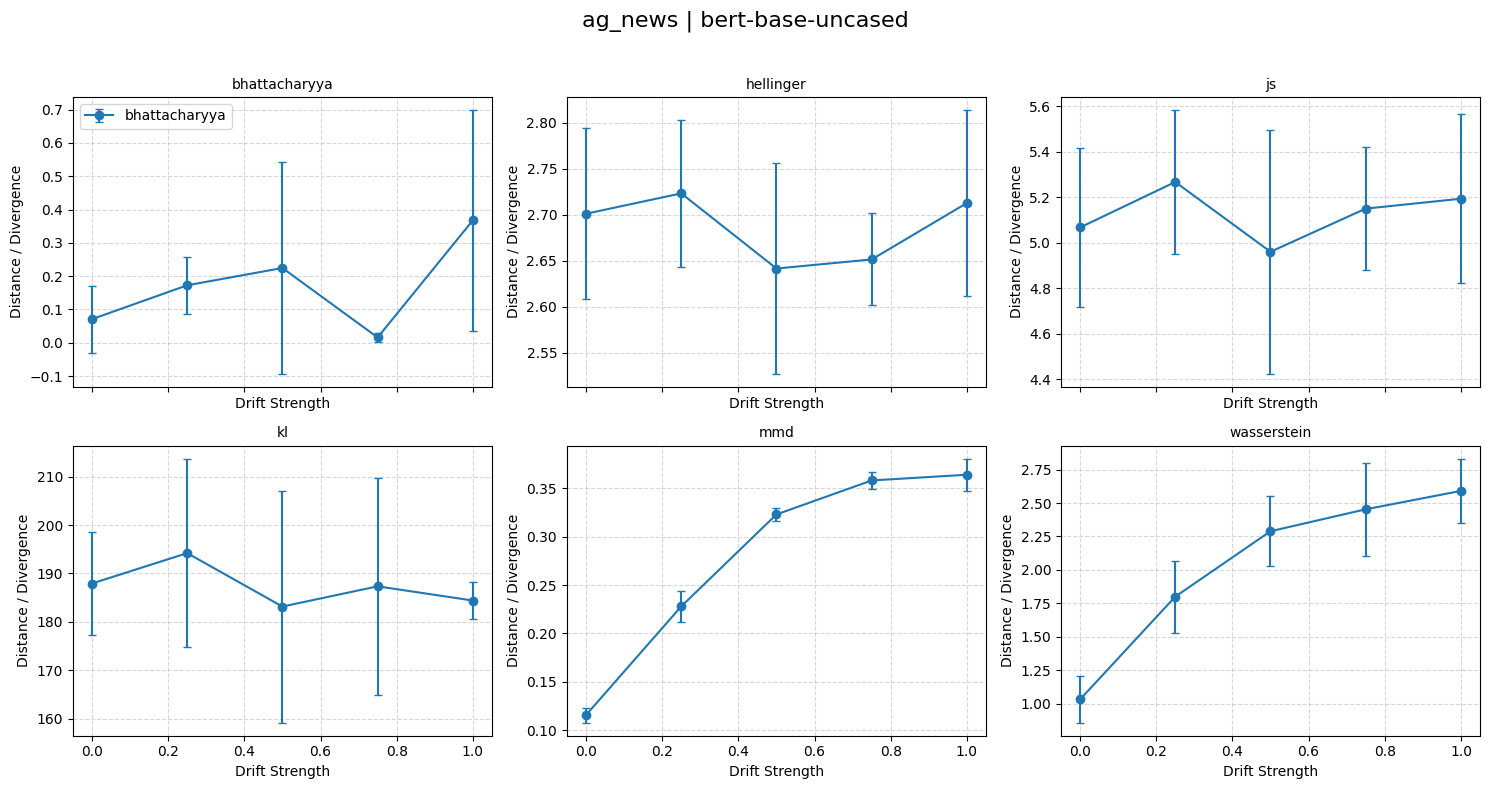

Saved figure: results_multidataset/ag_news_bert-base-uncased_distribution_measures.png


In [2]:
###############################################################################
# 7) Plot with Error Bars
###############################################################################
import math

def plot_distribution_distances(all_results, args):
    """
    We now have keys of the form:
       (dataset_name, model_name, measure_name, drift_strength) -> [dist_val_seed1, dist_val_seed2, ...]
    We'll group by dataset/model, then create subplots for each measure.
    """
    # Organize keys by (dataset_name, model_name)
    from collections import defaultdict
    plot_data = defaultdict(lambda: defaultdict(list))

    # Example: plot_data[(dataset_name, model_name)][measure_name] = list of (drift_strength, mean, std)
    for (dataset_name, model_name, measure_name, drift_strength), values in all_results.items():
        mean_val = np.mean(values)
        std_val  = np.std(values)
        plot_data[(dataset_name, model_name)][measure_name].append( (drift_strength, mean_val, std_val) )

    # Now we loop over each (dataset_name, model_name)
    for (dataset_name, model_name), measure_dict in plot_data.items():
        measure_names = sorted(measure_dict.keys())  # e.g. ['bhattacharyya','hellinger',...]
        n_measures = len(measure_names)

        n_cols = 3
        n_rows = math.ceil(n_measures / n_cols)

        fig, axs = plt.subplots(n_rows, n_cols,
                                figsize=(5 * n_cols, 4 * n_rows),
                                sharex=True)
        axs = axs.flatten()
        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16)

        for i, measure_name in enumerate(measure_names):
            ax = axs[i]
            data_points = measure_dict[measure_name]
            # Sort by drift_strength
            data_points = sorted(data_points, key=lambda x: x[0])
            x_vals = [dp[0] for dp in data_points]
            y_means = [dp[1] for dp in data_points]
            y_stds  = [dp[2] for dp in data_points]

            ax.errorbar(x_vals, y_means, yerr=y_stds,
                        fmt='-o', capsize=3, label=f"{measure_name}")

            ax.set_title(measure_name, fontsize=10)
            ax.set_xlabel("Drift Strength")
            ax.set_ylabel("Distance / Divergence")
            ax.grid(True, linestyle='--', alpha=0.5)
            if i == 0:
                ax.legend()

        for j in range(i+1, n_rows*n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        model_name_safe = model_name.replace("/", "_")
        fname = f"{dataset_name}_{model_name_safe}_distribution_measures.png"
        save_path = os.path.join(args["output_dir"], fname)
        plt.savefig(save_path)
        plt.show()
        print(f"Saved figure: {save_path}")

plot_distribution_distances(all_results, args)

/var/folders/2l/zhq3rqwj4_lg1b9s5c1yjqf00000gp/T/ipykernel_3668/133621858.py:50: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "-o" (-> marker='o'). The keyword argument will take precedence.
  ax.errorbar(x_vals, y_means, yerr=y_stds, fmt='-o', capsize=4,


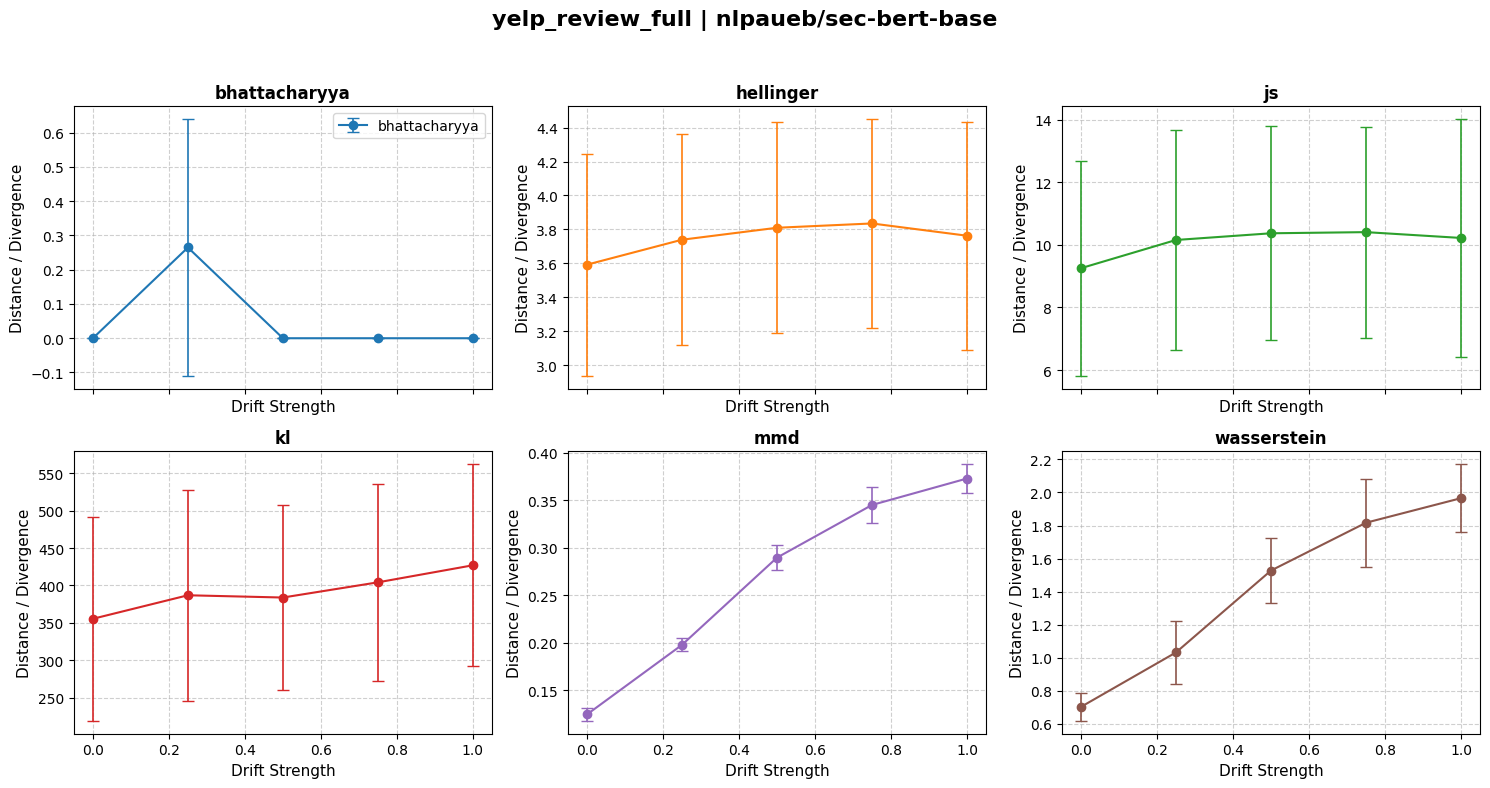

Saved figure: results_multidataset/yelp_review_full_nlpaueb_sec-bert-base_distribution_measures.png


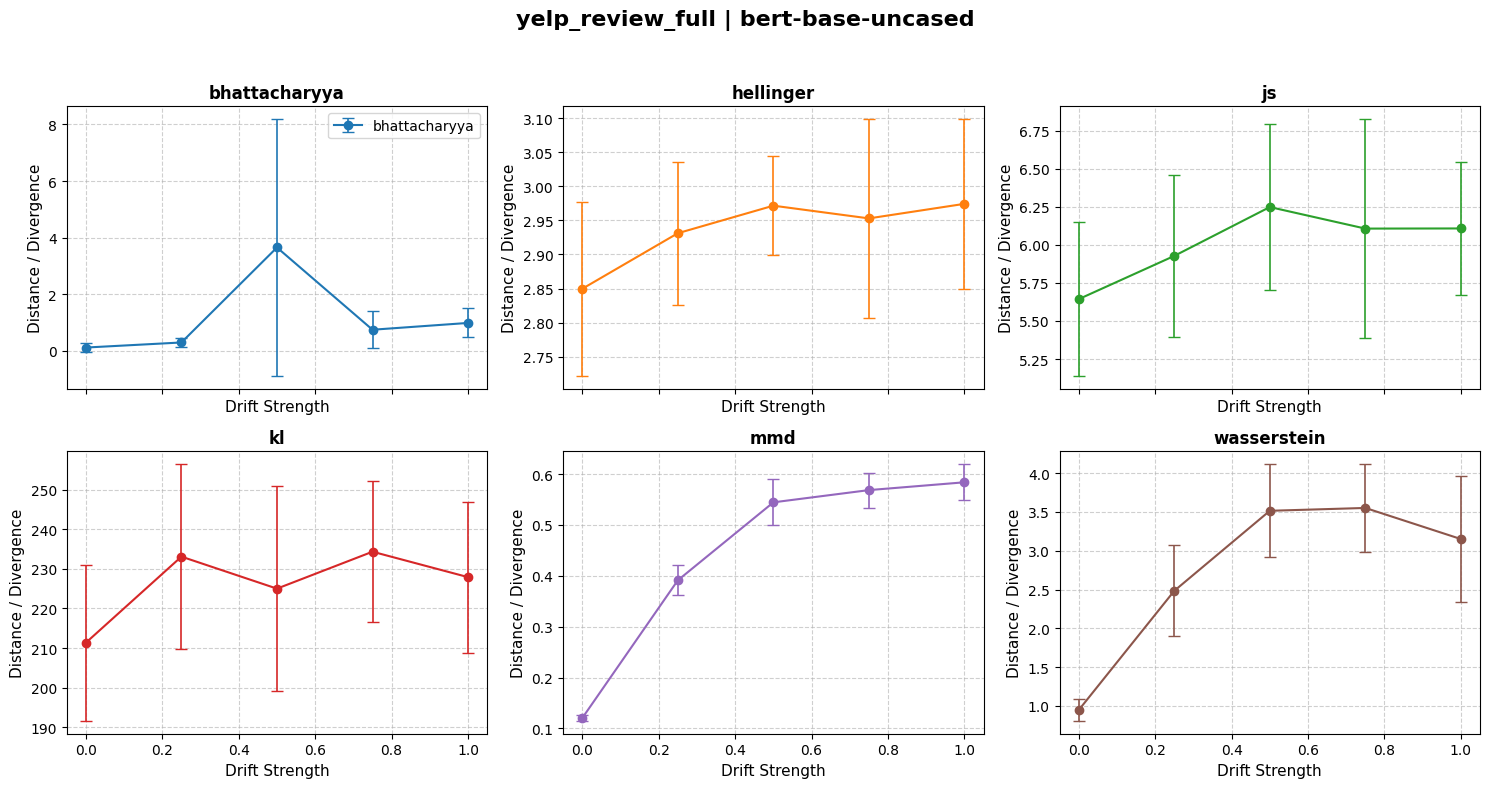

Saved figure: results_multidataset/yelp_review_full_bert-base-uncased_distribution_measures.png


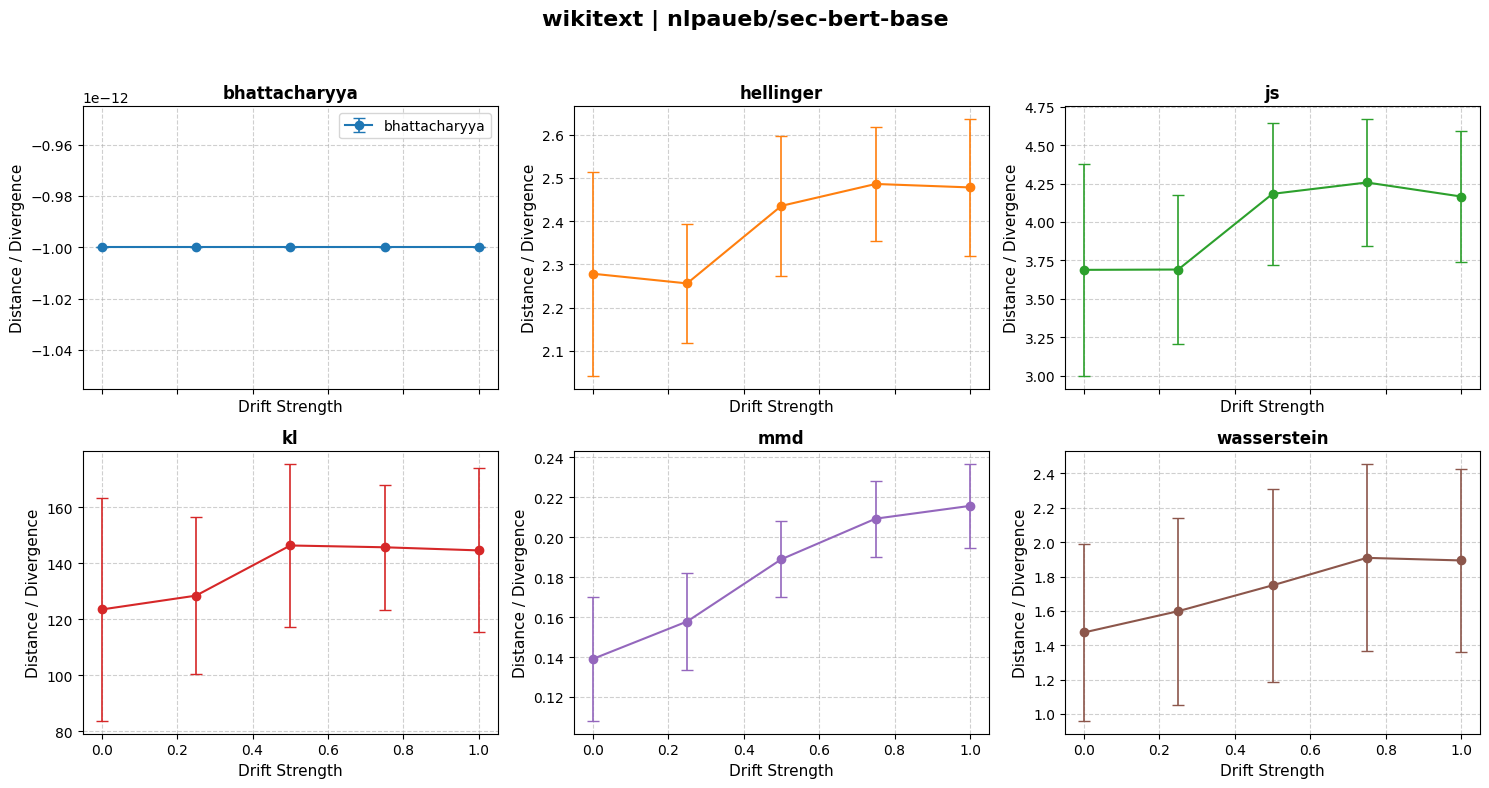

Saved figure: results_multidataset/wikitext_nlpaueb_sec-bert-base_distribution_measures.png


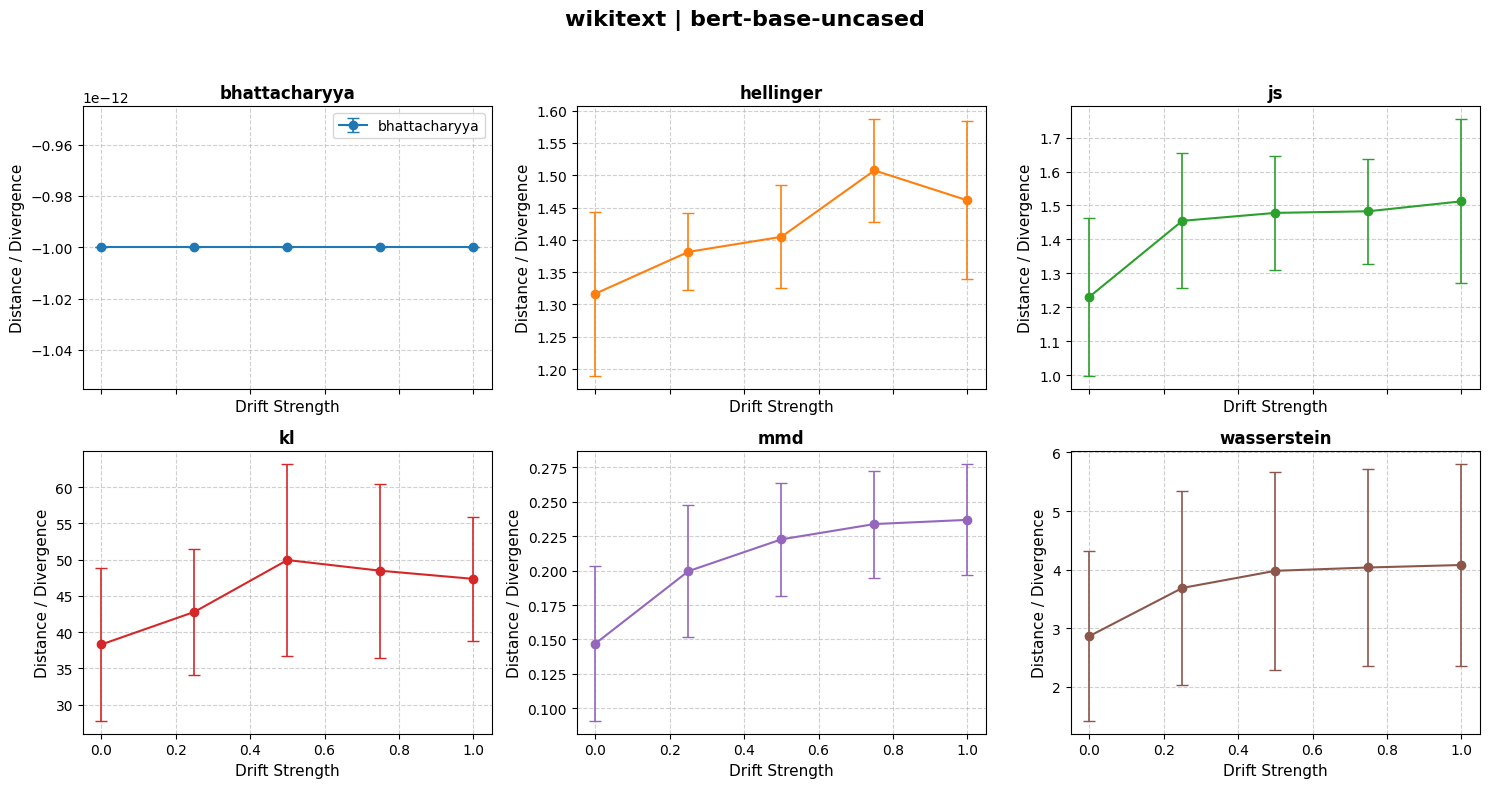

Saved figure: results_multidataset/wikitext_bert-base-uncased_distribution_measures.png


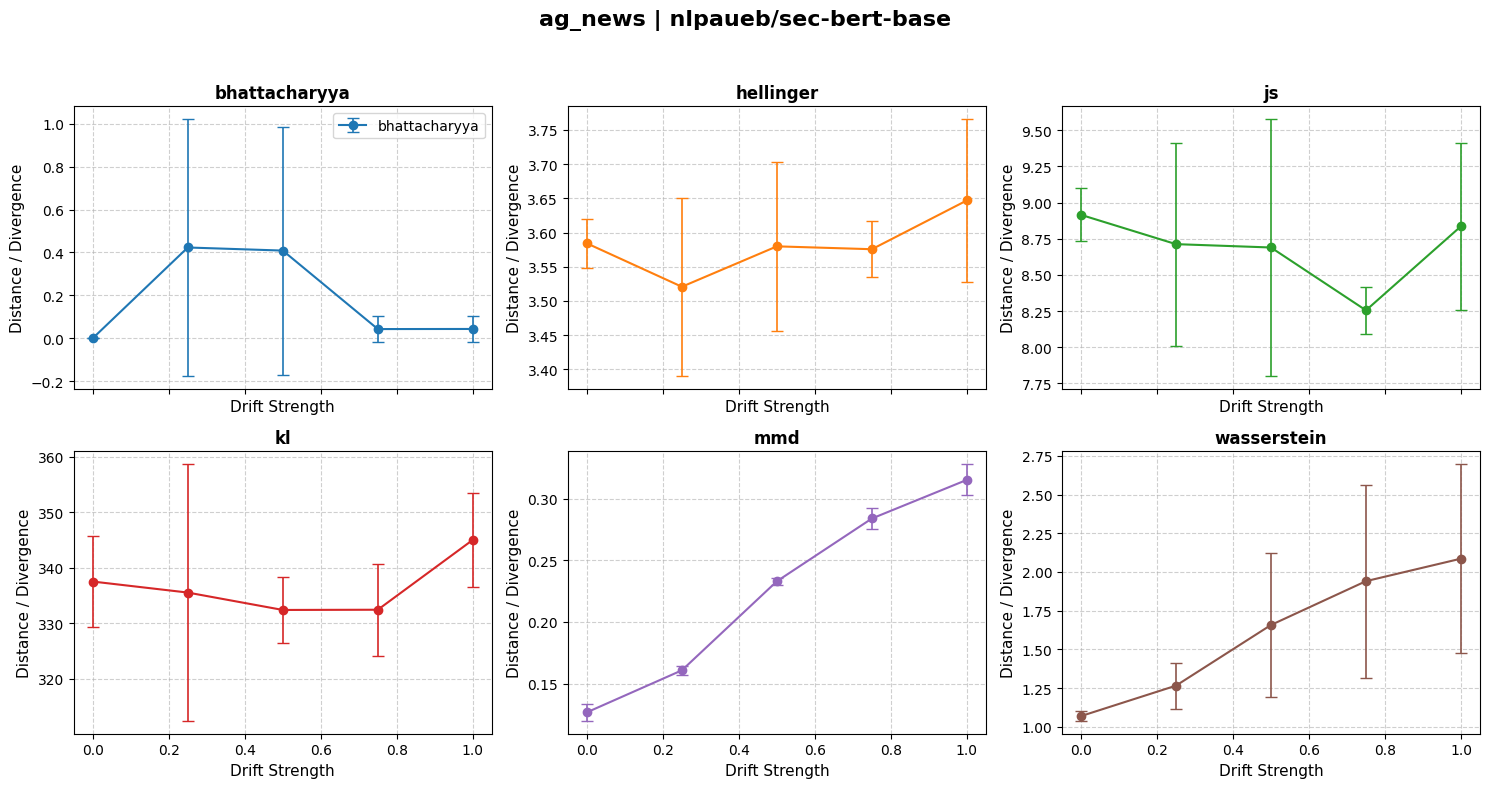

Saved figure: results_multidataset/ag_news_nlpaueb_sec-bert-base_distribution_measures.png


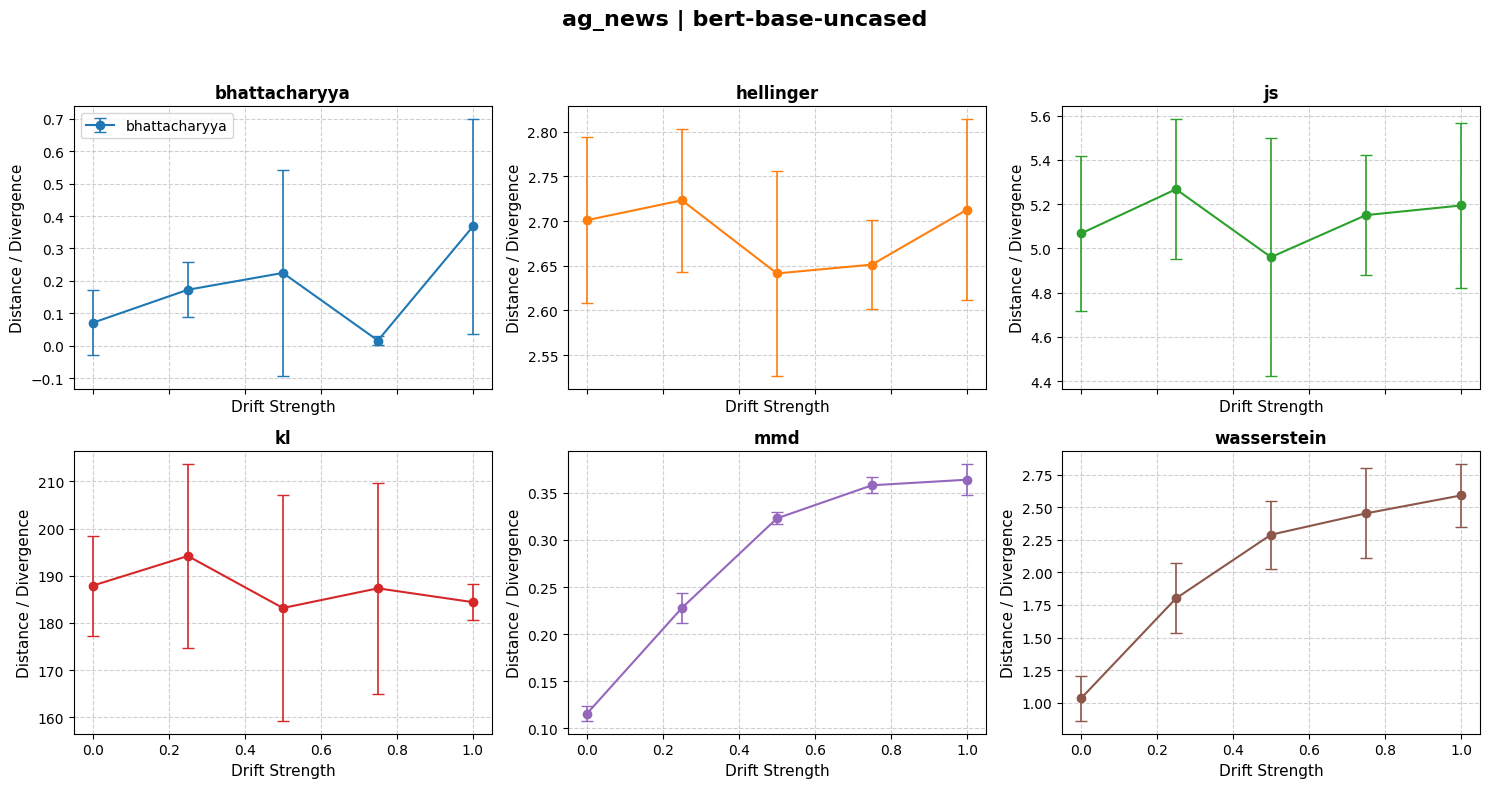

Saved figure: results_multidataset/ag_news_bert-base-uncased_distribution_measures.png


In [ ]:
def plot_distribution_distances2(all_results, args):
    """
    Generate subplots for each measure with error bars.
    """
    plot_data = defaultdict(lambda: defaultdict(list))

    # Organize the results
    for (dataset_name, model_name, measure_name, drift_strength), values in all_results.items():
        mean_val = np.mean(values)
        std_val = np.std(values)
        plot_data[(dataset_name, model_name)][measure_name].append((drift_strength, mean_val, std_val))

    # Iterate through dataset/model combinations
    for (dataset_name, model_name), measure_dict in plot_data.items():
        measure_names = sorted(measure_dict.keys())
        n_measures = len(measure_names)

        # Define grid layout
        n_cols = min(3, n_measures)  # Max 3 columns
        n_rows = math.ceil(n_measures / n_cols)

        # Adjust figure size dynamically
        fig, axs = plt.subplots(n_rows, n_cols,
                                figsize=(5 * n_cols, 4 * n_rows),
                                sharex=True)

        # Flatten the axes array in case of a single row
        axs = axs.flatten() if n_measures > 1 else [axs]

        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=16, fontweight='bold')

        # Define colors for consistency
        colors = plt.get_cmap("tab10")

        for i, measure_name in enumerate(measure_names):
            ax = axs[i]
            data_points = sorted(measure_dict[measure_name], key=lambda x: x[0])

            x_vals = [dp[0] for dp in data_points]
            y_means = [dp[1] for dp in data_points]
            y_stds = [dp[2] for dp in data_points]

            # Plot with error bars
            ax.errorbar(x_vals, y_means, yerr=y_stds, fmt='-o', capsize=4,
                        color=colors(i % 10), elinewidth=1.2, marker='o', markersize=6,
                        label=measure_name)

            ax.set_title(measure_name, fontsize=12, fontweight='bold')
            ax.set_xlabel("Drift Strength", fontsize=11)
            ax.set_ylabel("Distance / Divergence", fontsize=11)
            ax.grid(True, linestyle='--', alpha=0.6)

            if i == 0:
                ax.legend(fontsize=10)

        # Hide empty subplots
        for j in range(i + 1, n_rows * n_cols):
            axs[j].set_visible(False)

        # Improve layout
        plt.tight_layout(rect=[0, 0, 1, 0.95])

        # Save figure
        model_name_safe = model_name.replace("/", "_")
        fname = f"{dataset_name}_{model_name_safe}_distribution_measures.png"
        save_path = os.path.join(args["output_dir"], fname)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved figure: {save_path}")

plot_distribution_distances2(all_results, args)

/var/folders/2l/zhq3rqwj4_lg1b9s5c1yjqf00000gp/T/ipykernel_3668/4048869520.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_vals, y_means, yerr=y_stds, fmt='o-', capsize=3,


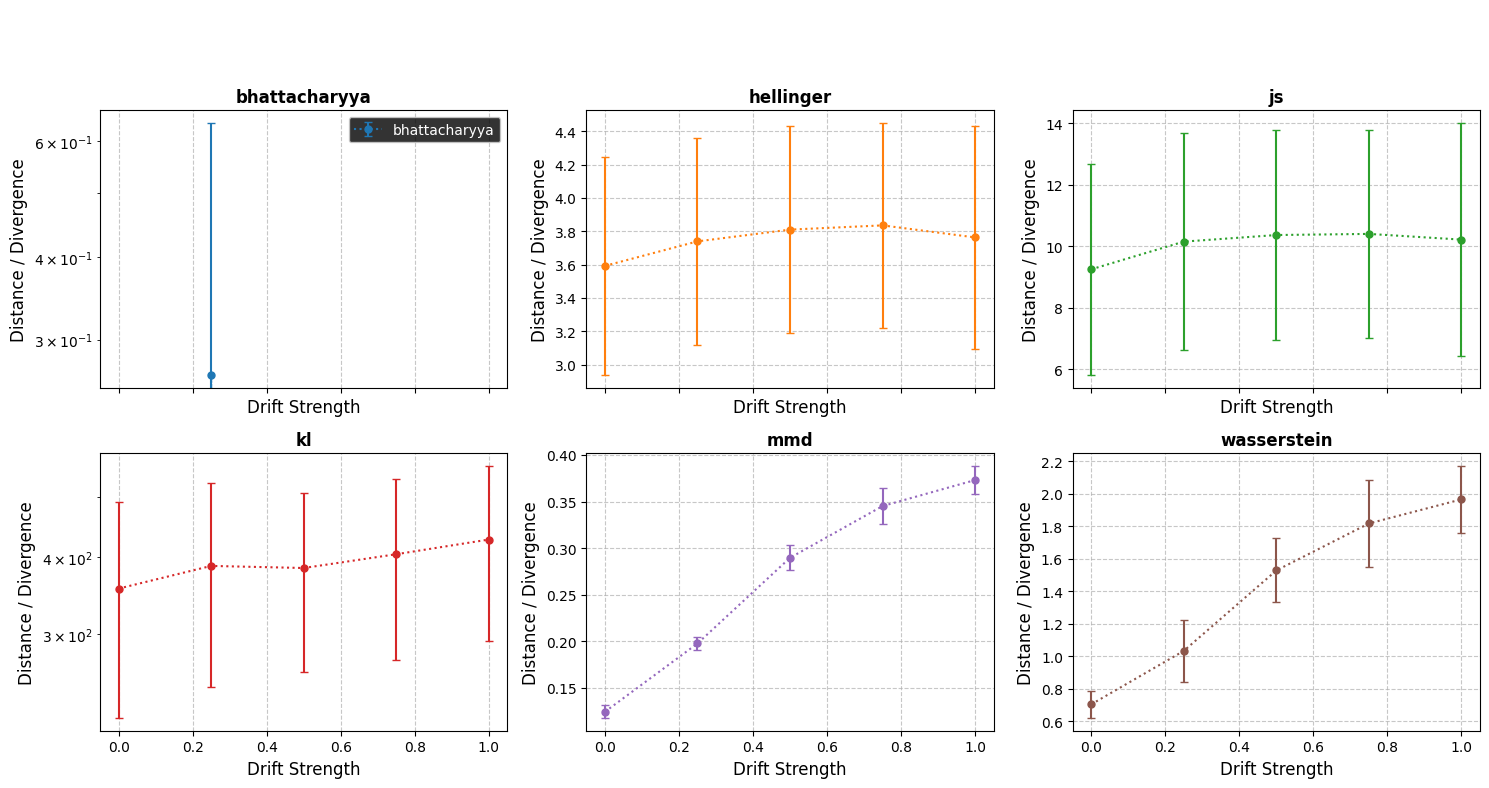

Saved figure: results_multidataset/yelp_review_full_nlpaueb_sec-bert-base_distribution_measures.png


/var/folders/2l/zhq3rqwj4_lg1b9s5c1yjqf00000gp/T/ipykernel_3668/4048869520.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_vals, y_means, yerr=y_stds, fmt='o-', capsize=3,


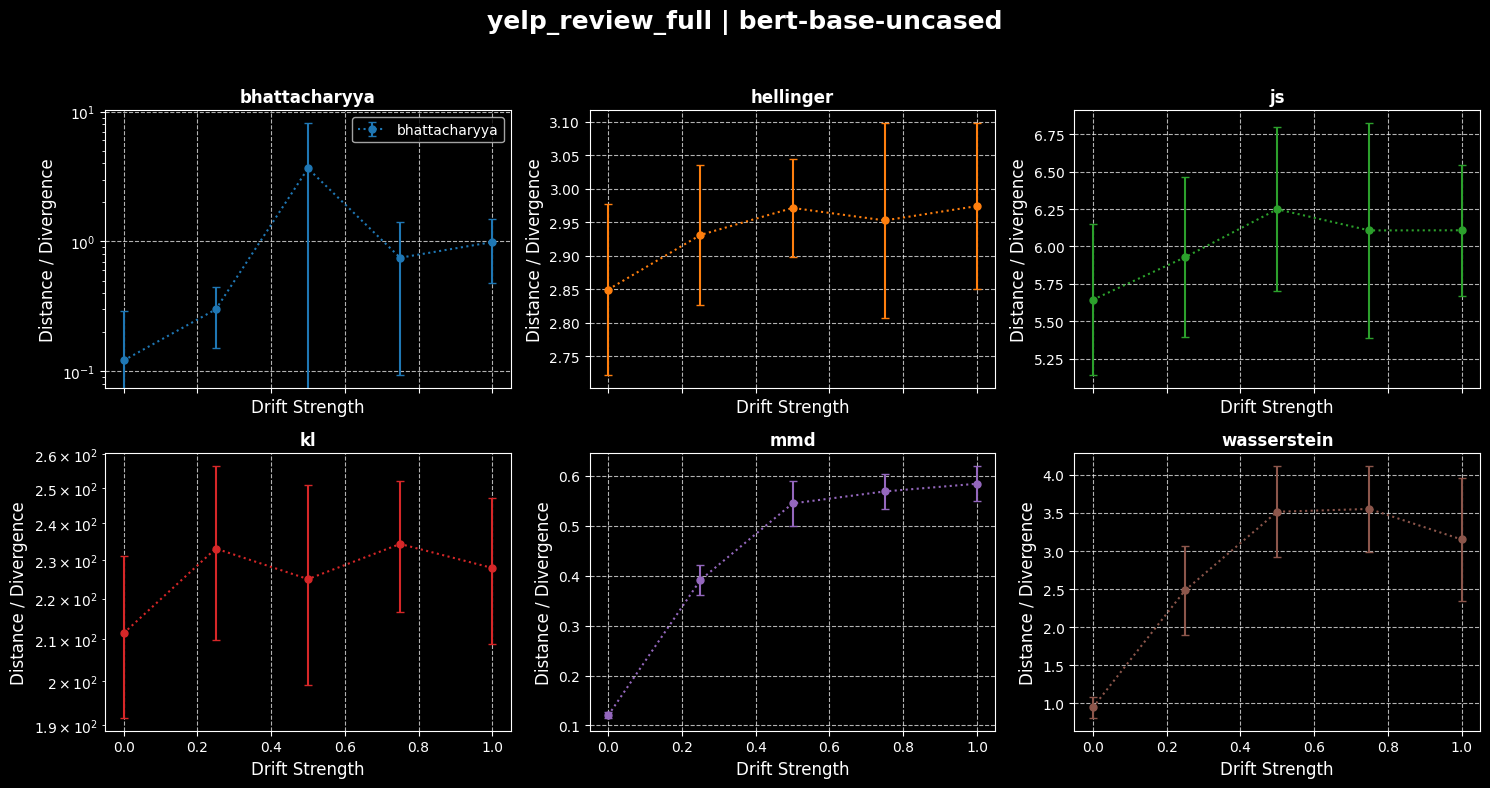

Saved figure: results_multidataset/yelp_review_full_bert-base-uncased_distribution_measures.png


/var/folders/2l/zhq3rqwj4_lg1b9s5c1yjqf00000gp/T/ipykernel_3668/4048869520.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_vals, y_means, yerr=y_stds, fmt='o-', capsize=3,
/var/folders/2l/zhq3rqwj4_lg1b9s5c1yjqf00000gp/T/ipykernel_3668/4048869520.py:60: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


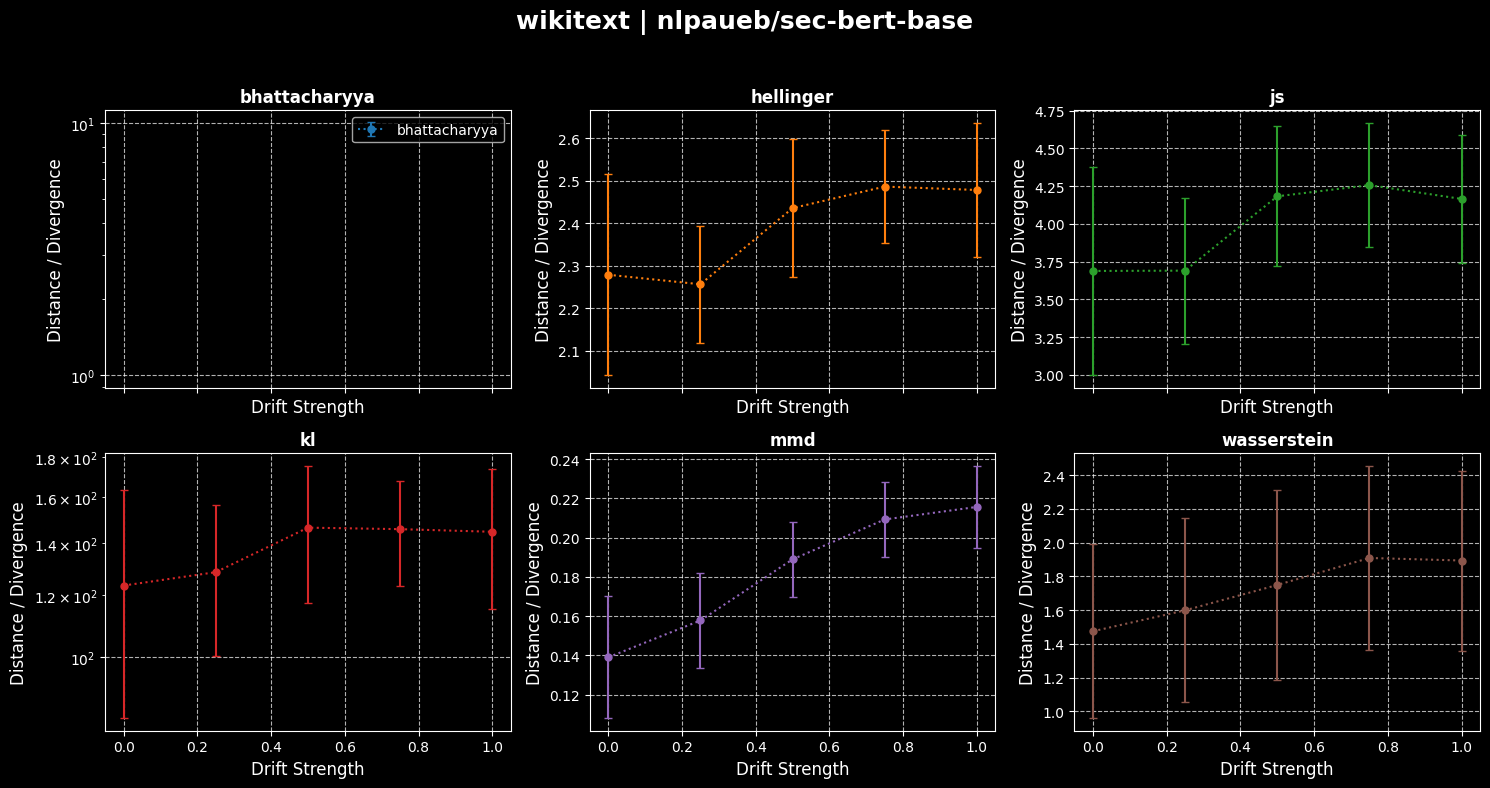

Saved figure: results_multidataset/wikitext_nlpaueb_sec-bert-base_distribution_measures.png


/var/folders/2l/zhq3rqwj4_lg1b9s5c1yjqf00000gp/T/ipykernel_3668/4048869520.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_vals, y_means, yerr=y_stds, fmt='o-', capsize=3,
/var/folders/2l/zhq3rqwj4_lg1b9s5c1yjqf00000gp/T/ipykernel_3668/4048869520.py:60: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


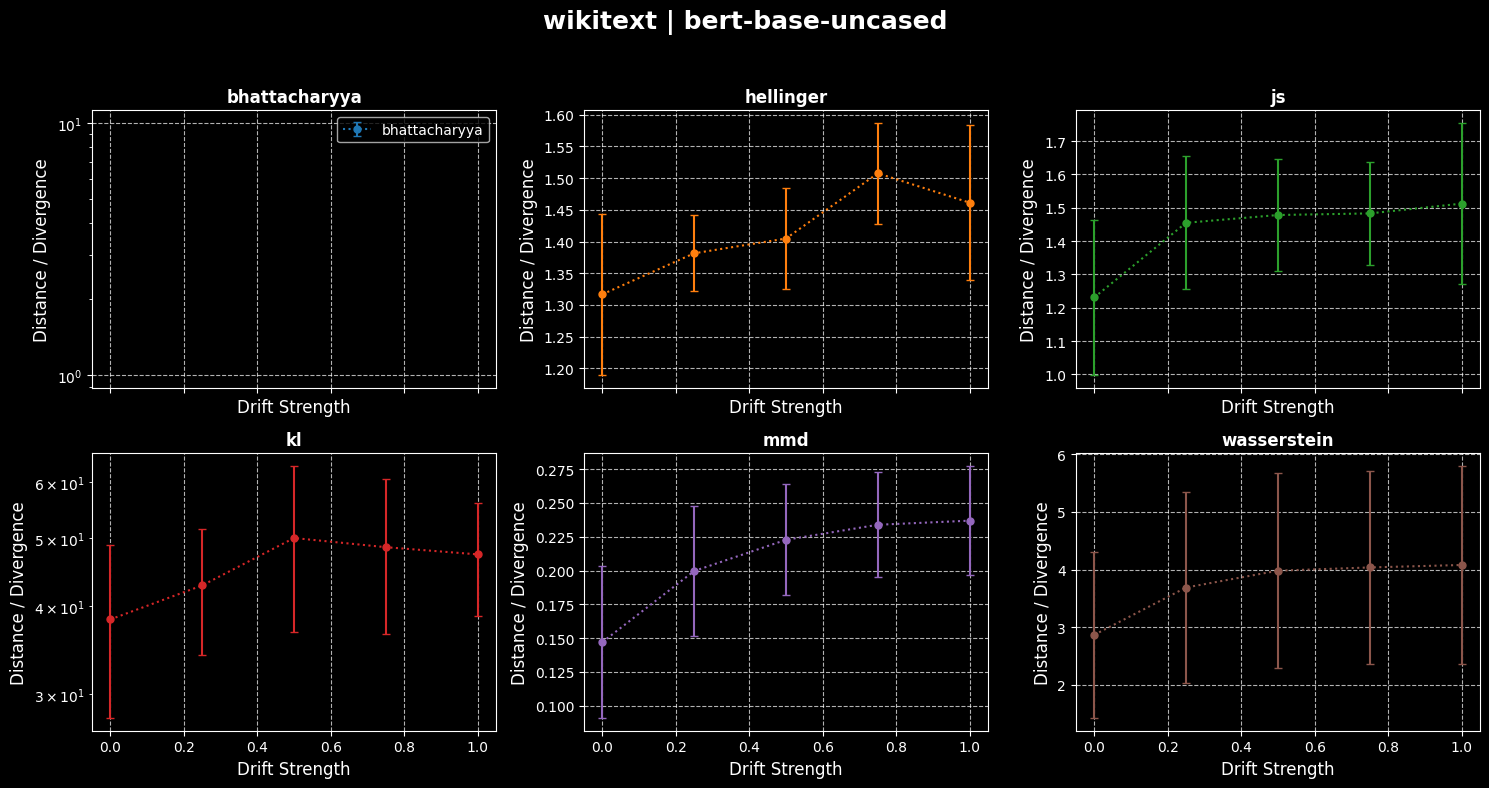

Saved figure: results_multidataset/wikitext_bert-base-uncased_distribution_measures.png


/var/folders/2l/zhq3rqwj4_lg1b9s5c1yjqf00000gp/T/ipykernel_3668/4048869520.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_vals, y_means, yerr=y_stds, fmt='o-', capsize=3,


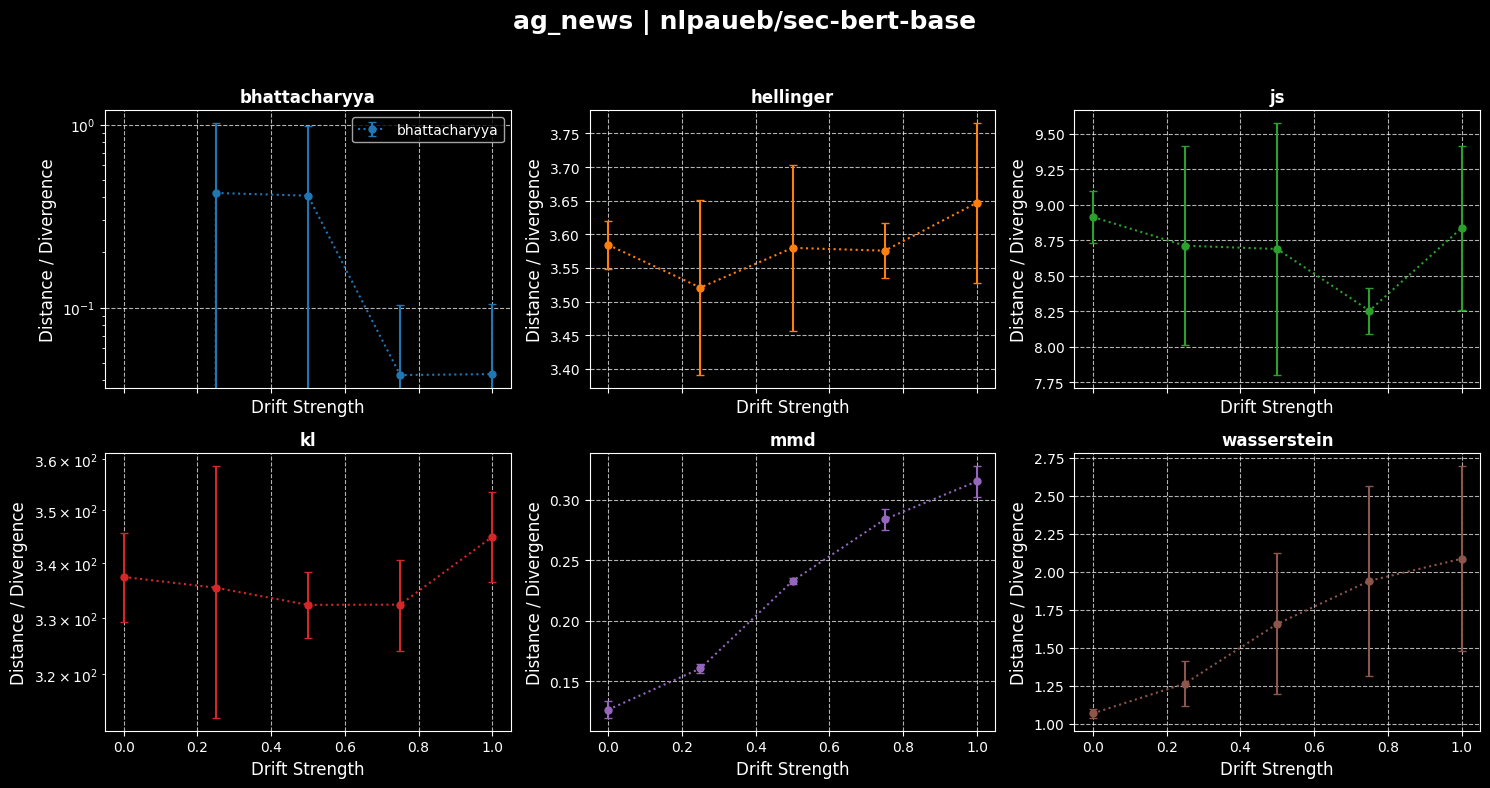

Saved figure: results_multidataset/ag_news_nlpaueb_sec-bert-base_distribution_measures.png


/var/folders/2l/zhq3rqwj4_lg1b9s5c1yjqf00000gp/T/ipykernel_3668/4048869520.py:49: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_vals, y_means, yerr=y_stds, fmt='o-', capsize=3,


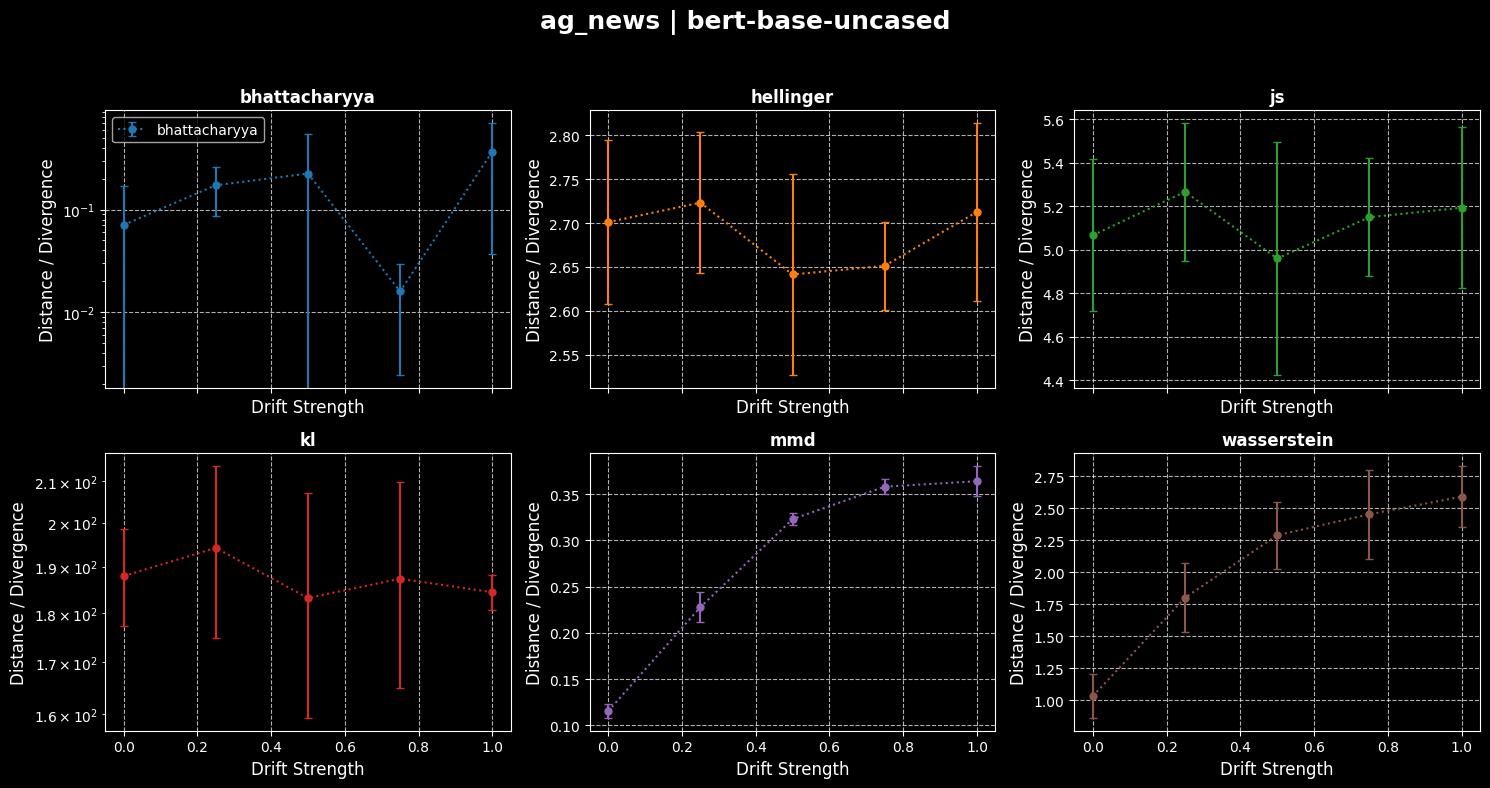

Saved figure: results_multidataset/ag_news_bert-base-uncased_distribution_measures.png


In [5]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_distribution_distances(all_results, args):
    """
    Generate subplots for each measure with refined styling and better readability.
    """
    plot_data = defaultdict(lambda: defaultdict(list))

    # Organize results
    for (dataset_name, model_name, measure_name, drift_strength), values in all_results.items():
        mean_val = np.mean(values)
        std_val = np.std(values)
        plot_data[(dataset_name, model_name)][measure_name].append((drift_strength, mean_val, std_val))

    # Iterate through dataset/model combinations
    for (dataset_name, model_name), measure_dict in plot_data.items():
        measure_names = sorted(measure_dict.keys())
        n_measures = len(measure_names)

        # Define grid layout
        n_cols = min(3, n_measures)  # Max 3 columns
        n_rows = math.ceil(n_measures / n_cols)

        # Adjust figure size dynamically
        fig, axs = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True)
        axs = axs.flatten() if n_measures > 1 else [axs]

        # Use a dark theme
        plt.style.use("dark_background")

        fig.suptitle(f"{dataset_name} | {model_name}", fontsize=18, fontweight='bold')

        # Define colors for consistency
        colors = plt.get_cmap("tab10")

        for i, measure_name in enumerate(measure_names):
            ax = axs[i]
            data_points = sorted(measure_dict[measure_name], key=lambda x: x[0])

            x_vals = [dp[0] for dp in data_points]
            y_means = [dp[1] for dp in data_points]
            y_stds = [dp[2] for dp in data_points]

            # Improve error bar style
            ax.errorbar(x_vals, y_means, yerr=y_stds, fmt='o-', capsize=3,
                        color=colors(i % 10), elinewidth=1.5, markersize=5, linestyle='dotted',
                        label=measure_name)

            ax.set_title(measure_name, fontsize=12, fontweight='bold')
            ax.set_xlabel("Drift Strength", fontsize=12)
            ax.set_ylabel("Distance / Divergence", fontsize=12)
            ax.grid(True, linestyle='--', alpha=0.7)

            # Apply log scaling for problematic measures
            if measure_name.lower() in ["kl", "bhattacharyya"]:
                ax.set_yscale("log")

            if i == 0:
                ax.legend(fontsize=10)

        # Hide empty subplots
        for j in range(i + 1, n_rows * n_cols):
            axs[j].set_visible(False)

        plt.tight_layout(rect=[0, 0, 1, 0.95])

        # Save figure
        model_name_safe = model_name.replace("/", "_")
        fname = f"{dataset_name}_{model_name_safe}_distribution_measures.png"
        save_path = os.path.join(args["output_dir"], fname)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved figure: {save_path}")

plot_distribution_distances(all_results, args)